In [3]:
%pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
import os
import json
import google.generativeai as genai
from dotenv import load_dotenv
import networkx as nx
import matplotlib.pyplot as plt
from pyvis.network import Network

/tmp/ipykernel_7319/1594796578.py:3: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


In [5]:
prompt_path = "prompt-v2.txt"
json_path = "mortgage-q10-blade/knowledge-graph.json"
error_path = "mortgage-q10-blade/knowledge-graph.txt"
graph_path = "mortgage-q10-blade/knowledge-graph.html"

In [6]:
%matplotlib inline

In [7]:
def convert_to_json(text):
    try:
        graph_json = json.loads(text)
    except json.JSONDecodeError:
        with open(error_path, "w", encoding="utf-8") as f:
            f.write(text)
        return
    
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(graph_json, f, indent=2)
    
    print("graph successfully saved to knowledge-graph-v2.")
    return graph_json

In [8]:
%pip install -U google-generativeai

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
%pip install -U google-generativeai

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.1/155.1 KB 2.2 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: google-generativeai
    Found existing installation: google-generativeai 0.8.5
    Uninstalling google-generativeai-0.8.5:
      Successfully uninstalled google-generativeai-0.8.5
Note: you may need to restart the kernel to use updated packages.


In [9]:
# DO NOT RUN UNLESS CALLING API

load_dotenv()
api_key = os.getenv("GEMINI_API_KEY")
if not api_key:
    exit

genai.configure(api_key=api_key)
model = genai.GenerativeModel("gemini-2.5-pro")

with open(prompt_path, "r", encoding="utf-8") as f:
    prompt = f.read()

print("Calling API:\n")
response = model.generate_content(prompt)
text = response.text
graph_json = convert_to_json(text)

Calling API:



ResourceExhausted: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/usage?tab=rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.5-pro
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.5-pro
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.5-pro
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.5-pro
Please retry in 43.726320384s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metr

In [35]:
try:
    with open(json_path, 'r') as file:
        graph_json = json.load(file)
except FileNotFoundError:
    print(f"Error: The file '{json_path}' was not found.")
except json.JSONDecodeError:
    print(f"Error: Failed to decode JSON from the file '{json_path}'. Check for malformed JSON.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

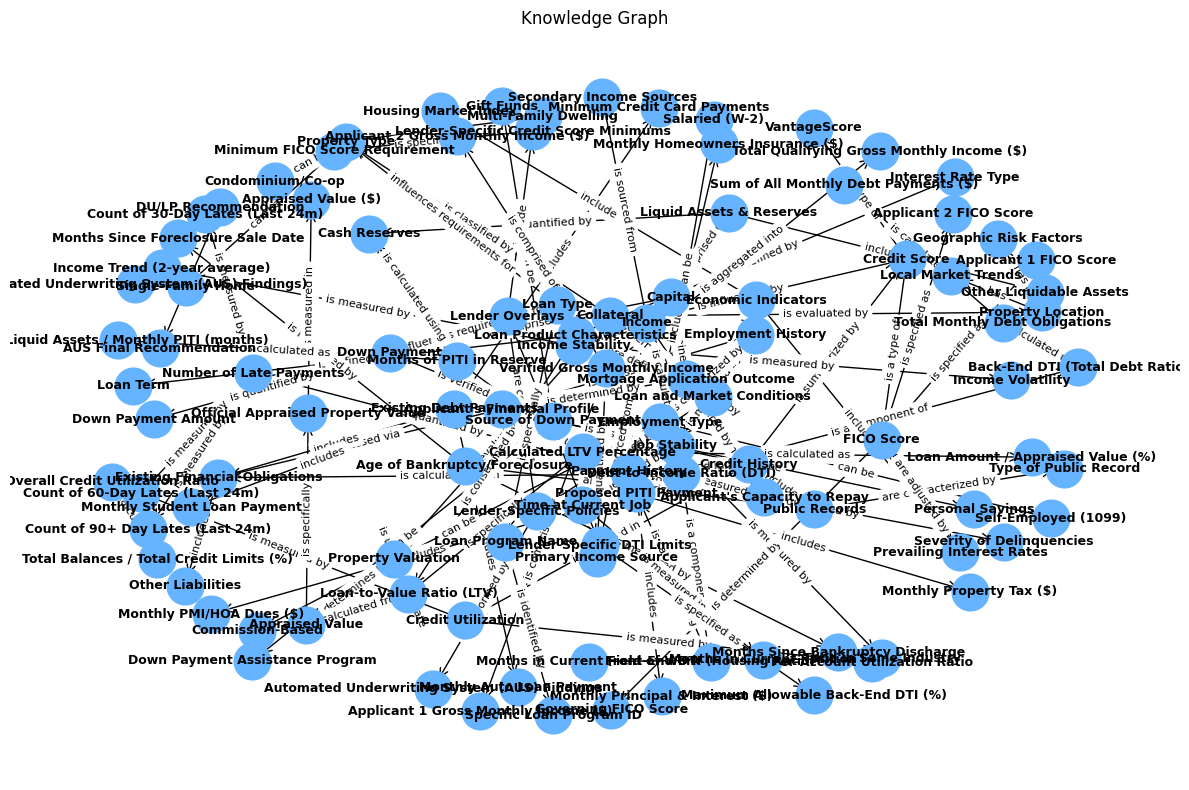

In [36]:
# build graph -> NetworkX library
G = nx.DiGraph()

for node, edges in graph_json.items():
    for edge in edges:
        neighbor = edge.get("neighbor")
        relation = edge.get("edge", "")
        if neighbor:
            G.add_node(node)
            G.add_node(neighbor)
            G.add_edge(node, neighbor, label=relation)

# visualize graph
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=0.5, iterations=50)
edge_labels = nx.get_edge_attributes(G, "label")

nx.draw_networkx_nodes(G, pos, node_size=700, node_color="#66b3ff")
nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle="->", arrowsize=15)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

plt.title("Knowledge Graph")
plt.axis("off")
plt.tight_layout()
plt.show()


In [37]:
net = Network(height="750px", width="100%", directed=True, bgcolor="#ffffff", font_color="#000000")
net.from_nx(G)

net.repulsion(
    node_distance=150,
    central_gravity=0.33,
    spring_length=200,
    spring_strength=0.05,
    damping=0.95
)

for src, dst, data in G.edges(data=True):
    label = data.get("label", "")
    if label:
        net.edges[-1]["title"] = label

net.show(graph_path, notebook=False)


mortgage-q10/knowledge-graph.html


In [38]:
# go through the generated graph and manually perform a cycle detection algorithm that prints out
# the cycles found

cycles = list(nx.simple_cycles(G))
if cycles:
    print("Cycles detected in the graph:")
    for cycle in cycles:
        print(" -> ".join(cycle))
else:
    print("No cycles detected in the graph.")

Cycles detected in the graph:
Cash Reserves -> Months of PITI in Reserve


In [39]:
# go through the generated graph and manually perform a cycle detection algorithm that prints out
# the cycles found

cycles = list(nx.simple_cycles(G))
if cycles:
    print("Cycles detected in the graph:")
    for cycle in cycles:
        print(" -> ".join(cycle))
else:
    print("No cycles detected in the graph.")

Cycles detected in the graph:
Cash Reserves -> Months of PITI in Reserve


In [40]:
# delete edges if they form cycles
for cycle in cycles:
    for i in range(len(cycle)):
        src = cycle[i]
        dst = cycle[(i + 1) % len(cycle)]
        if G.has_edge(src, dst):
            G.remove_edge(src, dst)
            print(f"Removed edge from {src} to {dst} to break the cycle.")
            break


Removed edge from Cash Reserves to Months of PITI in Reserve to break the cycle.


In [42]:
net.show(graph_path, notebook=False)

mortgage-q10/knowledge-graph.html
